## DCGAN

In [ ]:
!# uv pip install torchsummary torcheval

In [3]:
import os
from collections import defaultdict
from PIL import Image
from IPython import display
import time
import numpy as np

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as Transforms

from matplotlib import pyplot as plt

from torchsummary import summary
from torcheval import metrics as Metrics

### Parametros de treino

In [4]:
DATA_DIR = '/data/desenv/2026/iagenerativa/lego-bricks-images-dataset/dataset'
IMAGE_SIZE = 64
CHANNELS = 1
BATCH_SIZE = 128
Z_DIM = 100
NOISE_PARAM = 0.1
EPOCHS = 300
ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.999
LR = 2e-4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cpu'

### Dataset customizado

#### Classe `LegoData` 

A classe `LegoData` é uma implementação personalizada de um **dataset do PyTorch**, herdando de `torch.utils.data.Dataset`.  
Ela é responsável por:

- carregar imagens de um diretório  
- aplicar pré-processamento  
- fornecer os dados de forma estruturada para treinamento  

---

#### Estrutura geral

Ela implementa três métodos principais:

- `__init__`: inicialização
- `__len__`: retorna o tamanho do dataset
- `__getitem__`: retorna uma amostra

#### Método `__init__`

Inicializa o dataset com o diretório de imagens.

- Armazena o caminho das imagens
- Lista todos os arquivos do diretório
- Calcula o número total de imagens

Também define um pipeline de transformações:

- Conversão para tensor
- Redimensionamento
- Conversão para escala de cinza
- Normalização

#### Transformações

As transformações aplicadas são:

- `ToTensor()`: converte a imagem para tensor
- `Resize`: ajusta o tamanho da imagem
- `Grayscale`: reduz para 1 canal
- `Normalize`: normaliza os valores para [-1, 1]

#### Método `__len__`

Retorna a quantidade total de imagens no dataset.

#### Método `__getitem__`

Responsável por:

1. Selecionar a imagem pelo índice
2. Construir o caminho completo
3. Abrir a imagem
4. Aplicar transformações
5. Retornar o tensor

#### Fluxo

Diretório → lista de arquivos → leitura → transformação → tensor

#### Tipo de Dataset

Este é um dataset não supervisionado, pois não possui labels.


In [5]:

class LegoData(Dataset):

    def __init__(self, image_dir):
        super().__init__()
        self.image_dir = image_dir
        self.imgs = os.listdir(self.image_dir)
        self.length = len(self.imgs)

        # Transformações para as imagens
        self.transform = Transforms.Compose([
                            Transforms.ToTensor(),
                            Transforms.Resize(size=(IMAGE_SIZE, IMAGE_SIZE), antialias=None),
                            Transforms.Grayscale(num_output_channels=1),
                            Transforms.Normalize((0.5), (0.5))])

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        img_file = os.path.join(self.image_dir, self.imgs[index])
        img = Image.open(img_file)
        img = self.transform(img)
        return img

In [6]:
def get_dataloader():
    lego_dataset = LegoData(DATA_DIR)
    train_loader = DataLoader(lego_dataset, batch_size=BATCH_SIZE, num_workers=8,
                              shuffle=True, pin_memory=True)
    print('Tamanho dos dados de treino: ', len(lego_dataset))
    print('Num. batchs de treino: ', len(train_loader))
    return train_loader

In [8]:
def display_imgs(imgs):
    plt.figure(figsize=(16, 3))
    for i in range(8):
        ax = plt.subplot(1, 8, i+1)
        ax.imshow(imgs[i][0], cmap='gray')
        ax.axis('off')
    plt.show()

# plot amostras de treino
def show_records(history):
    plt.figure(figsize=(16, 3))
    for i, key in enumerate(history):
        ax = plt.subplot(1, len(history), i+1)
        ax.plot(history[key])
        ax.set_title(key)
    plt.show()

Tamanho dos dados de treino:  40000
Num. batchs de treino:  313
torch.Size([128, 1, 64, 64])


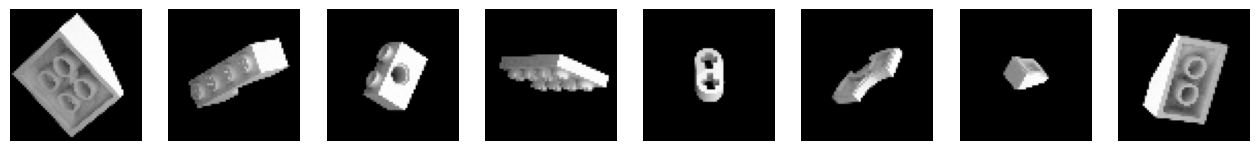

In [9]:
# Verificando o dataloader e plotando algumas amostras
train_loader = get_dataloader()
check_sample = next(iter(train_loader))
print(check_sample.shape)
display_imgs(check_sample)

## 2. Building GAN

In [10]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        channel_list = [CHANNELS, 64, 128, 256, 512]
        
        # Camadas convolucionais para o discriminador
        # Observe essa maneira de usar nn.Sequential para criar blocos de camadas, 
        # o que torna o código mais limpo e organizado.
        # Redes modernas são compostas por blocos de camadas, e essa abordagem 
        # facilita a construção desses blocos. 
        self.conv_layers = nn.Sequential()
        for i in range(len(channel_list) - 1):
            conv_block = self.get_conv_block(channel_list[i], channel_list[i+1], bool(i))
            self.conv_layers.add_module(f'conv_block_{i}', conv_block)

        # Camadas para a saída -> (Batch_size, 1)
        self.output_layers = nn.Sequential(
            nn.Conv2d(in_channels=channel_list[-1], out_channels=1, 
                      kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid(),  # Para limitar a saída entre 0 e 1, 
                           # indicando a probabilidade de ser real ou falso
            nn.Flatten()
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.output_layers(x)
        return x    

    def get_conv_block(self, in_ch, out_ch, use_bn=False):
        conv_layer = nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=4,
                               stride=2, padding=1, bias=False)
        batch_norm = nn.BatchNorm2d(num_features=out_ch, momentum=0.1)
        leaky_relu = nn.LeakyReLU(negative_slope=0.2)
        dropout_2d = nn.Dropout2d(p=0.3)
        
        conv_block = [conv_layer, batch_norm, leaky_relu, dropout_2d] if use_bn else [conv_layer, leaky_relu, dropout_2d] 
        return nn.Sequential(*conv_block)

# test = Discriminator().to(DEVICE)
# summary(test, (1, 64, 64))

In [11]:
class Generator(nn.Module):

    def __init__(self, z_dim):
        super().__init__()
        channel_list = [z_dim, 512, 256, 128, 64]

        # Camadas de Convolution transpose construídas em blocos, similar ao discriminador
        self.trans_conv_layers = nn.Sequential()
        for i in range(len(channel_list) - 1):
            stride = 2 if i else 1
            padding = 1 if i else 0
            trans_conv_block = self.get_transpose_conv_block(channel_list[i], channel_list[i + 1],
                                                             stride, padding)
            self.trans_conv_layers.add_module(f'trans_conv_block_{i}', trans_conv_block)

        # Camadas de saída -> (-1, 1, 64, 64)
        self.output_layers = nn.Sequential(
                nn.ConvTranspose2d(in_channels=channel_list[-1], out_channels=CHANNELS,
                                   kernel_size=4, stride=2, padding=1, bias=False),
                nn.Tanh()
        )


    def forward(self, x):
        x = x.reshape(x.shape[0], x.shape[-1], 1, 1)
        x = self.trans_conv_layers(x)
        x = self.output_layers(x)
        return x

    
    def get_transpose_conv_block(self, in_ch, out_ch, stride=2, padding=1):
        transpose_conv = nn.ConvTranspose2d(in_channels=in_ch, out_channels=out_ch,
                                            kernel_size=4, stride=stride, padding=padding, bias=False)
        batch_norm = nn.BatchNorm2d(num_features=out_ch, momentum=0.1)
        leaky_relu = nn.LeakyReLU(negative_slope=0.2)
        return nn.Sequential(transpose_conv, batch_norm, leaky_relu)

# generator = Generator(Z_DIM).to(DEVICE)
# summary(generator, (100,))

In [ ]:
class DCGAN(nn.Module):
    
    def __init__(self, z_dim):
        super().__init__()
        self.z_dim = z_dim
        self.generator = Generator(z_dim)
        self.discriminator = Discriminator()


    def forward(self, real_imgs):
        latents = torch.randn(size=(len(real_imgs), self.z_dim)).to(DEVICE)
        generated_imgs = self.generator(latents)

        real_preds = self.discriminator(real_imgs)
        fake_preds = self.discriminator(generated_imgs)
        
        return real_preds, fake_preds, generated_imgs

dcgan = DCGAN(Z_DIM).to(DEVICE)
summary(dcgan, (1, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 512, 4, 4]         819,200
       BatchNorm2d-2            [-1, 512, 4, 4]           1,024
         LeakyReLU-3            [-1, 512, 4, 4]               0
   ConvTranspose2d-4            [-1, 256, 8, 8]       2,097,152
       BatchNorm2d-5            [-1, 256, 8, 8]             512
         LeakyReLU-6            [-1, 256, 8, 8]               0
   ConvTranspose2d-7          [-1, 128, 16, 16]         524,288
       BatchNorm2d-8          [-1, 128, 16, 16]             256
         LeakyReLU-9          [-1, 128, 16, 16]               0
  ConvTranspose2d-10           [-1, 64, 32, 32]         131,072
      BatchNorm2d-11           [-1, 64, 32, 32]             128
        LeakyReLU-12           [-1, 64, 32, 32]               0
  ConvTranspose2d-13            [-1, 1, 64, 64]           1,024
             Tanh-14            [-1, 1,

### Define modelo e parametros de treino: objetivo, e otimizadores

In [ ]:
dcgan = DCGAN(Z_DIM).to(DEVICE)

if torch.__version__.split('.')[0] == '2':
    torch.set_float32_matmul_precision('high')
    # It is important to use eager backend here to avoid
    # distribution mismatch in training and predicting
    dcgan = torch.compile(dcgan, backend='eager')
    print('modelo compilado')

loss_fn = nn.BCELoss()
d_optim = torch.optim.Adam(params=dcgan.discriminator.parameters(), lr=LR, betas=(ADAM_BETA_1, ADAM_BETA_2))
g_optim = torch.optim.Adam(params=dcgan.generator.parameters() ,lr=LR, betas=(ADAM_BETA_1, ADAM_BETA_2))

train_metrics = {
    'd_loss': Metrics.Mean(),
    'g_loss': Metrics.Mean(),
    'd_real_acc': Metrics.BinaryAccuracy(),
    'd_fake_acc': Metrics.BinaryAccuracy(),
    'g_acc': Metrics.BinaryAccuracy(),
}

model compiled


#### dataloader

In [25]:
lego_dataloader = get_dataloader()

Train data size:  40000
Num. train batchs:  313


### Funcao de treino

In [12]:
from tqdm import tqdm

def train(model, dataloader, d_optim, g_optim, loss_fn, train_metrics):
    
    model.train() # Set model to train mode
    
    for metric in train_metrics.values():
        metric.reset() # clear metrics data

    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    
    for i, train_imgs in enumerate(progress_bar):
        train_imgs = train_imgs.to(DEVICE)

        # # Discriminator
        model.discriminator.zero_grad()
        real_preds = model.discriminator(train_imgs)

        # # obtém perda com dataset real
        real_labels = torch.ones_like(real_preds, dtype=torch.float)
        # adiciona leve ruído às labels reais para estabilizar o treinamento do discriminador,
        # o que é uma técnica comum para evitar que o discriminador se torne muito confiante
        real_noisy_labels = real_labels + NOISE_PARAM * torch.randn(size=real_labels.shape, device=DEVICE)
        real_noisy_labels = torch.clamp(real_noisy_labels, 0.0, 1.0)
        
        # 1a. Loss com imagens reais
        d_real_loss = loss_fn(real_preds.reshape(-1), real_noisy_labels.reshape(-1))
        d_real_loss.backward()

        # 1b. Loss com imagens geradas (fake_preds conectado ao discriminador,
        #     mas NÃO ao generator — geradas sem grafo via no_grad)
        with torch.no_grad():
            latents = torch.randn(train_imgs.size(0), model.z_dim, device=DEVICE)
            generated_imgs = model.generator(latents)
        # gerado sem grafo, então fake_preds só conecta ao discriminador
        fake_preds = model.discriminator(generated_imgs)
        fake_labels = torch.zeros_like(fake_preds, dtype=torch.float)
        # fake_noisy_labels = fake_labels - NOISE_PARAM * torch.randn(size=fake_labels.shape, device=DEVICE)
        # fake_noisy_labels = torch.clamp(fake_noisy_labels, 0.0, 1.0)
        fake_noisy_labels = torch.clamp(
            fake_labels + NOISE_PARAM * torch.randn_like(fake_labels), 0.0, 1.0
        )
   
        d_fake_loss = loss_fn(fake_preds.reshape(-1), fake_noisy_labels.reshape(-1))
        d_fake_loss.backward()  # gradientes acumulados no discriminador

        d_loss = d_real_loss + d_fake_loss  # só para métricas
        d_optim.step()

        # Generator
        model.generator.zero_grad()

        # Novo forward pass completo — grafo limpo, conectado ao generator
        latents = torch.randn(train_imgs.size(0), model.z_dim, device=DEVICE)
        generated_imgs = model.generator(latents)       # COM grafo
        fake_preds_for_g = model.discriminator(generated_imgs)
        # generator quer enganar o discriminador → label = 1
        g_loss = loss_fn(
            fake_preds_for_g.reshape(-1),
            torch.ones(fake_preds_for_g.reshape(-1).shape[0], device=DEVICE)
        )
        g_loss.backward()
        g_optim.step()

        # atualiza métricas
        train_metrics['d_loss'].update(d_loss.detach().cpu())
        train_metrics['g_loss'].update(g_loss.detach().cpu())
        train_metrics['d_fake_acc'].update(fake_preds.reshape(-1).detach().cpu(), fake_labels.reshape(-1).detach().cpu())
        train_metrics['d_real_acc'].update(real_preds.reshape(-1).detach().cpu(), real_labels.reshape(-1).detach().cpu())
        train_metrics['g_acc'].update(fake_preds_for_g.reshape(-1).detach().cpu(),
                                      torch.ones(fake_preds_for_g.reshape(-1).shape[0]))

        del d_loss, g_loss, fake_preds, fake_preds_for_g, real_preds
        del real_labels, real_noisy_labels, fake_labels, fake_noisy_labels

    return generated_imgs

## 6. Train DCGAN

Época: 300	dur. época 0.55 min
	 d_loss: 0.4184 | g_loss: 3.4231 | d_real_acc: 0.9918 | d_fake_acc: 0.9934 | g_acc: 0.0046 |


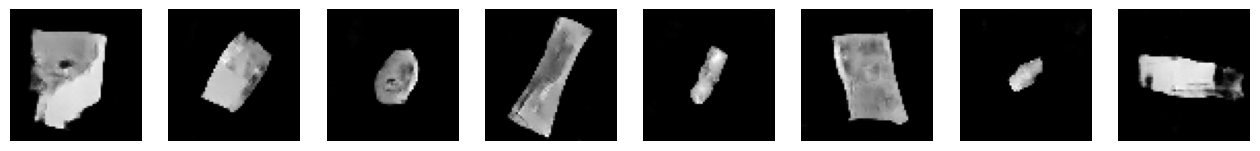

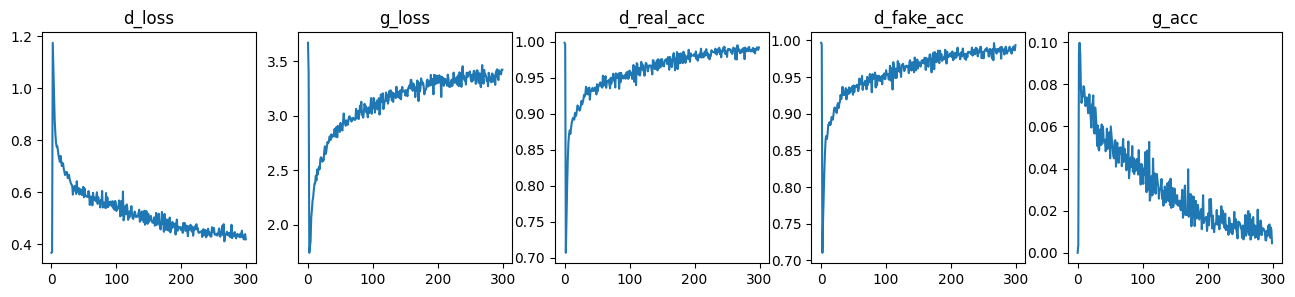

In [ ]:
history = defaultdict(list)

for i in range(EPOCHS):
    prev_time = time.time()
    generated_imgs = train(dcgan, lego_dataloader, d_optim, g_optim, loss_fn, train_metrics)
    curr_time = time.time()
    
    for key, value in train_metrics.items():
        history[key].append(value.compute().item())

    display.clear_output(wait=True)

    print('Época: {}\tdur. época {:.2f} min'.format(i+1, (curr_time - prev_time) / 60))
    metrics = [f'{key}: {value.compute().item():.4f} | ' for key, value in train_metrics.items()]
    print('\t', ''.join(metrics))
    
    generated_imgs = generated_imgs.detach().cpu()
    display_imgs(generated_imgs)
    show_records(history)
    
# tempo total de treino: 173 minutos (2h53min) para 300 épocas

In [ ]:
# torch.save(dcgan.state_dict(), './dcgan.pth')

### Gerando novas imagens

In [ ]:
# amostragem do vetor latente usando distr normal
grid_width, grid_height = (10, 3)
z_samples = torch.randn(size=(grid_width * grid_height, Z_DIM), device=DEVICE)
generated_imgs = dcgan.generator(z_samples)

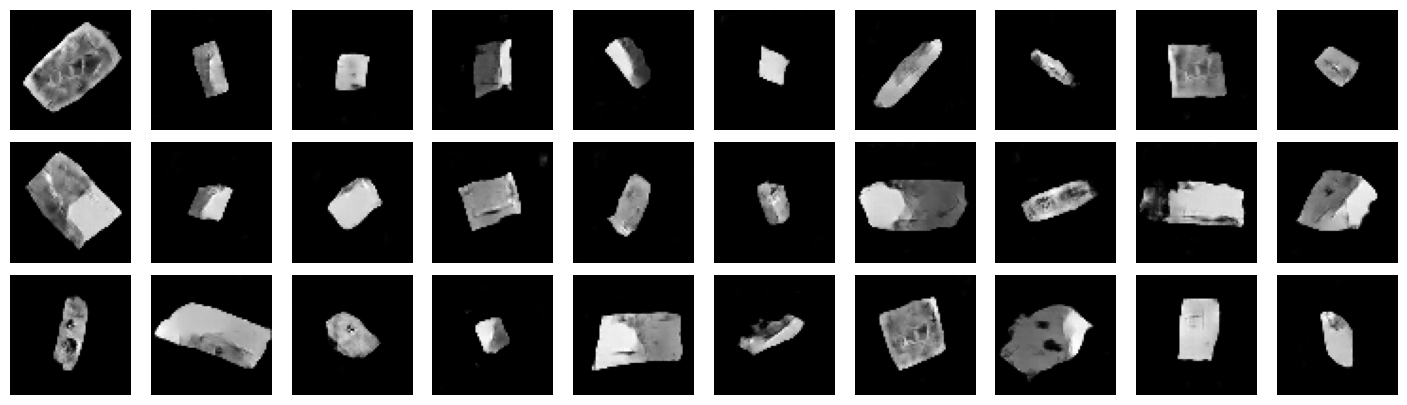

In [ ]:
# Plota imagens geradas
fig = plt.figure(figsize=(18, 5))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

for i in range(grid_width * grid_height):
    ax = fig.add_subplot(grid_height, grid_width, i + 1)
    ax.axis("off")
    ax.imshow(generated_imgs[i][0].detach().cpu(), cmap="gray")

### Comparando imagens geradas 

obtem mais próximas no dataset usando distância L1

In [36]:
total_imgs = None
for i, sample_batch in enumerate(lego_dataloader):
    if i == 0:
        total_imgs = sample_batch
    else:
        total_imgs = torch.cat([total_imgs, sample_batch], dim=0)
print(total_imgs.shape)

torch.Size([40000, 1, 64, 64])


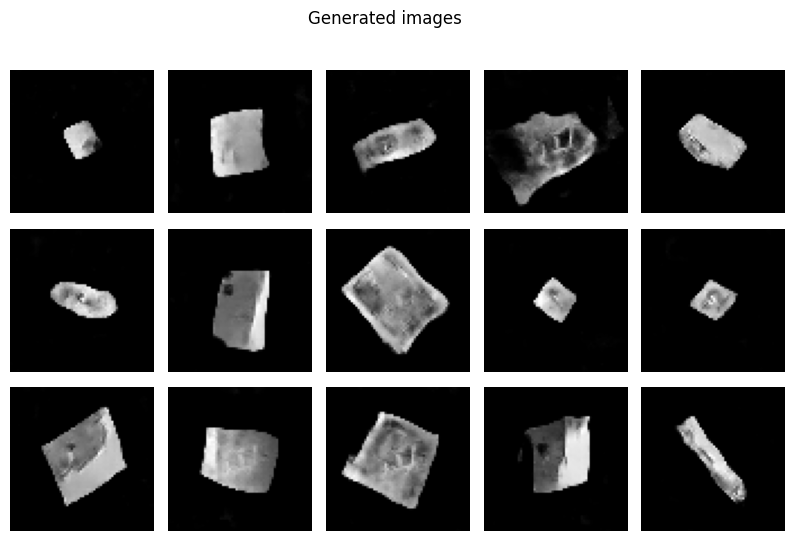

In [ ]:
grid_width, grid_height = (5, 3)
z_samples = torch.randn(size=(grid_width * grid_height, Z_DIM), device=DEVICE)
dcgan.eval()
with torch.no_grad():
    generated_imgs = dcgan.generator(z_samples).detach().cpu()

# Plota imagens geradas (decodificadas)
fig = plt.figure(figsize=(10, 6))
fig.subplots_adjust(hspace=0.1, wspace=0.1)
fig.suptitle('Imagens Geradas')

# Grid
for i in range(grid_width * grid_height):
    ax = fig.add_subplot(grid_height, grid_width, i + 1)
    ax.axis("off")
    ax.imshow(generated_imgs[i][0], cmap="gray")

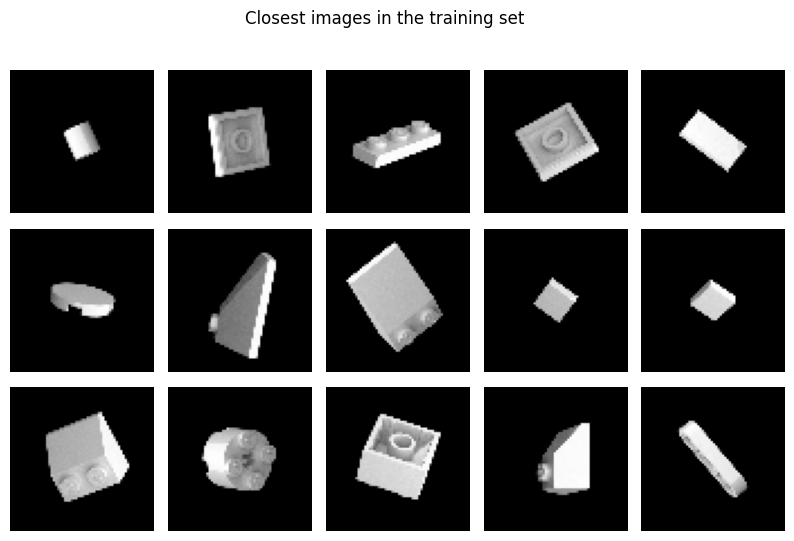

In [ ]:
# Desenha imagens geradas
fig = plt.figure(figsize=(10, 6))
fig.subplots_adjust(hspace=0.1, wspace=0.1)
fig.suptitle('Imagens mais próximas do dataset de')

# Grid
for i in range(grid_width * grid_height):
    ax = fig.add_subplot(grid_height, grid_width, i + 1)
    ax.axis("off")
    # compara imagens
    gen_img = generated_imgs[i].unsqueeze(0)
    L1_dist = (total_imgs - gen_img).abs().reshape(total_imgs.shape[0], -1).mean(dim=1)
    selection = L1_dist.argmin().item()
    
    ax.imshow(total_imgs[selection][0], cmap="gray")